In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import os
import matplotlib.patheffects as pe

from clim_functions import day_plot


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')


In [4]:
df_eddies[df_eddies.Day==6206].fname.iloc[0]

'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06201.nc'

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


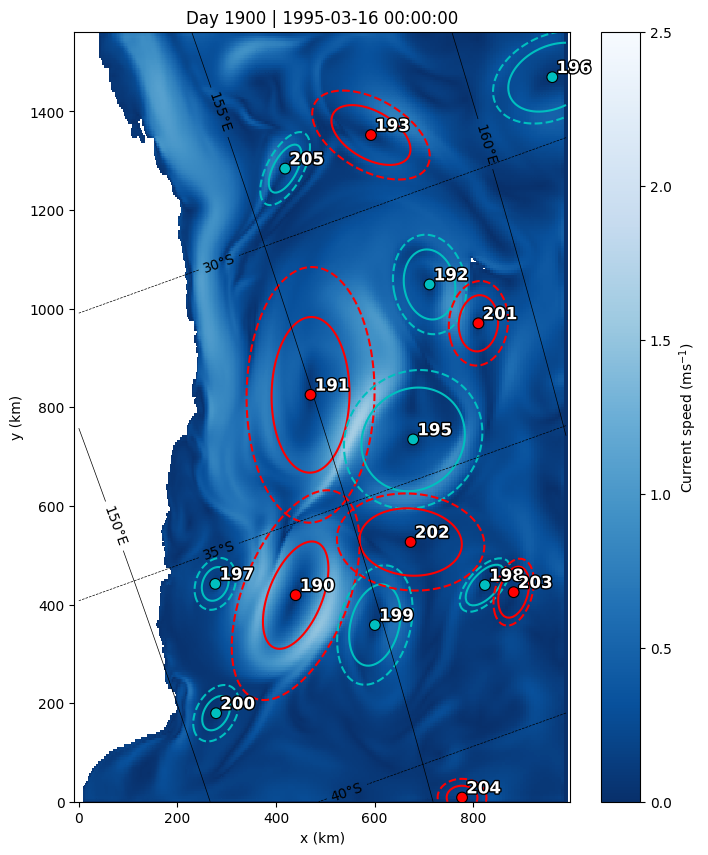

In [5]:
day_plot(1900, df_eddies, out_core_flag=True)


In [6]:
def file_save_plots(fname, df_eddies, out_core_flag=False, dpi=120, annotate=False):

    out_dir = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/daily_snapshots'
    os.makedirs(out_dir, exist_ok=True)

    with nc.Dataset(fname) as ds:

        ocean_time = ds['ocean_time'][:] / 86400
        available_days = ocean_time.astype(int)

        df_file = df_eddies.loc[df_eddies.Day.isin(available_days)].copy()

        if len(df_file) == 0:
            return

        for day in np.sort(df_file.Day.unique()):

            t = np.where(ocean_time == day)[0][0]

            ut = ds['u_eastward'][t, -1, :, :].T
            vt = ds['v_northward'][t, -1, :, :].T
            cs = np.hypot(ut, vt)

            df_day = df_file.loc[df_file.Day.eq(day)].copy()

            if 'Q' not in df_day.columns:
                df_day['Q'] = list(
                    np.stack([
                        np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                        np.stack([df_day.q12.values, df_day.q22.values], axis=1)
                    ], axis=1)
                )

            fig, ax = plt.subplots(figsize=(8, 10))

            im = ax.pcolormesh(
                X_grid, Y_grid, cs,
                shading='auto',
                vmin=0, vmax=2.5,
                cmap='Blues_r',
                rasterized=True
            )

            fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

            clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')

            ax.scatter(
                df_day.xc, df_day.yc,
                c=clrs,
                edgecolors='k',
                linewidths=0.5,
                s=35,
                zorder=10
            )

            for xc, yc, e, Q, Rc, R, cyc in zip(
                df_day.xc,
                df_day.yc,
                df_day.Eddy,
                df_day.Q,
                df_day.Rc,
                df_day.R,
                df_day.Cyc
            ):

                dx = X_grid - xc
                dy = Y_grid - yc

                rho2 = (
                    Q[0, 0] * dx**2
                    + 2 * Q[1, 0] * dx * dy
                    + Q[1, 1] * dy**2
                )

                clr = 'r' if cyc == 'AE' else 'c'

                ax.contour(
                    X_grid, Y_grid, rho2,
                    levels=[Rc**2 / 2],
                    colors=clr,
                    linewidths=1
                )

                if out_core_flag:
                    ax.contour(
                        X_grid, Y_grid, rho2,
                        levels=[(1.75 * R)**2],
                        colors=clr,
                        linestyles='--',
                        linewidths=0.8
                    )

                if annotate:
                    ax.text(
                        xc, yc, str(e),
                        fontsize=8,
                        color='w',
                        weight='bold',
                        ha='left',
                        va='bottom',
                        zorder=11
                    )

            ax.contour(
                X_grid, Y_grid, lat_rho,
                levels=[-40, -35, -30, -25],
                colors='k',
                linewidths=0.4
            )

            ax.contour(
                X_grid, Y_grid, lon_rho,
                levels=[150, 155, 160],
                colors='k',
                linewidths=0.4
            )

            date = pd.Timestamp("1990-01-01") + pd.Timedelta(days=int(day))
            ax.set_title(f'Day {int(day)} | {date:%Y-%m-%d}')

            ax.set_aspect('equal')
            ax.set_xlabel('x (km)')
            ax.set_ylabel('y (km)')
            ax.set_xlim(x_grid.min(), x_grid.max())
            ax.set_ylim(y_grid.min(), y_grid.max())

            save_path = f'{out_dir}/Day{int(day):05}.png'
            fig.savefig(save_path, dpi=dpi)
            plt.close(fig)
            

In [7]:
start_fname = df_eddies.loc[df_eddies.Day == 6189, 'fname'].iloc[0]

fnames = df_eddies.fname.unique()

fnames_from_start = fnames[np.where(fnames == start_fname)[0][0]:]

fnames_from_start


array(['/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06171.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06201.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06231.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06261.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06291.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06321.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06351.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06381.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06411.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06441.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06471.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06501.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06531.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06561.nc',
       '/srv/scratch/z3533156/26year_BRAN2020/outer_avg_06591.

In [ ]:
# for fn in df_eddies.fname.unique():
#     file_save_plots(fn, df_eddies, out_core_flag=False, dpi=120, annotate=True)

for fn in fnames_from_start:
    file_save_plots(fn, df_eddies, out_core_flag=False, dpi=120, annotate=True)
    

/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N

In [ ]:
# for day in range(3545, 10650 + 1):
#     day_save_plot(day, df_eddies, out_core_flag=True)
    